# Liga MX Corner Kick Analysis

**Data:** 8 temporadas de Liga MX (4 años) · StatsBomb 360 · 2021/22 – 2024/25  
**Objetivo:** Transformar 13 279 tiros de esquina en recomendaciones tácticas accionables usando OBV, xG y datos espaciales 360.

---

| Sección | Contenido |
|---|---|
| 0. Referencia técnica | Coordenadas, posiciones tácticas, tipos de envío, OBV, clusters |
| 1. Setup | Librerías y rutas |
| 2. Carga | Lectura de parquets raw y JSON |
| 3. Filtrado | Aislar córneres, clasificar remates y construir datasets |
| 4. EDA | Distribución por equipo, temporada, tipo de envío |
| 5. Efectividad | OBV, xG, tasa de remate y riesgo de contraataque |
| 6. Análisis espacial | Posicionamiento 360 y freeze frames |
| 7. Modelo | Random Forest + SHAP: qué predice el peligro |
| 8. Recomendaciones | Cambio de mix táctico con estimación de impacto |
| 9. Visualización | Pitch maps y gráficas para coaches |

## 0 · Referencia técnica

Convenciones de datos StatsBomb usadas en este análisis. Sirve como guía de consulta durante el desarrollo.

---

### 0.1 · Contexto

Análisis de tiros de esquina en Liga MX para la clase de Sports Analytics (ITAM). Los datos provienen de la competencia ISAC 2025 "Turning Corners into Goals" (8 temporadas Liga MX, StatsBomb 360).

| Eje de análisis | Qué buscamos |
|---|---|
| Relevancia táctica | Insights accionables para coaches: qué tipo de envío funciona y cuándo |
| Metodología | Usar OBV para valorar el 100% de córneres, no solo los que rematan |
| Riesgo-recompensa | Comparar tasa de remate vs tasa de contraataque por tipo |
| Modelo predictivo | RF + SHAP: qué variables explican el peligro generado |

**Ventaja de este análisis:** la mayoría de análisis de córneres usa solo xG - eso cubre 5,607 remates y descarta 7,672 córneres que no terminaron en remate. OBV asigna valor a cada evento individual, por lo que captura todos los outcomes: gol, despeje, contraataque, retención de posesión.

---

### 0.2 · Coordenadas del campo (Pitch Coordinates)

Pitch StatsBomb: **120 × 80 yards**. Origen en esquina superior izquierda `(0, 0)`. El equipo atacante siempre ataca de izquierda a derecha (x = 0 → 120). Banderines de córner atacante: `(120, 0)` y `(120, 80)`.

![Pitch Coordinates](figures/specs_pitch_coordinates.png)

---

### 0.3 · Coordenadas del arco (Goal Coordinates)

Los remates usan coordenadas 3D `[x, y, z]` para la ubicación de destino:
- `x = 120` — línea de gol
- `y` entre 36 y 44 — ancho del arco (8 yards)
- `z` entre 0 y 2.67 — altura del travesaño

![Goal Coordinates](figures/specs_goal_coordinates.png)

---

### 0.4 · Posiciones tácticas

StatsBomb codifica 25 posiciones usadas en `tactics`, `shot_freeze_frame` y `position`.

![Tactical Positions](figures/specs_tactical_positions.png)

| ID | Pos | ID | Pos | ID | Pos | ID | Pos | ID | Pos |
|---|---|---|---|---|---|---|---|---|---|
| 1 | GK | 6 | LB | 11 | LDM | 16 | LM | 21 | LW |
| 2 | RB | 7 | RWB | 12 | RM | 17 | RW | 22 | RCF |
| 3 | RCB | 8 | LWB | 13 | RCM | 18 | RAM | 23 | ST |
| 4 | CB | 9 | RDM | 14 | CM | 19 | CAM | 24 | LCF |
| 5 | LCB | 10 | CDM | 15 | LCM | 20 | LAM | 25 | SS |

---

### 0.5 · Cross y Cutback

**Cross** (`pass_cross = True`): pase desde zona atacante (x > 84) que intersecta el área central. La mayoría de envíos inswinging/outswinging al área califican como cross.

![Cross Definition](figures/specs_cross.png)

**Cutback** (`pass_cut_back = True`): pase bajo hacia atrás desde el fondo del área. Patrón típico de córner corto → fondo → recentro.

![Cutback Definition](figures/specs_cutback.png)

---

### 0.6 · Tipos de envío (`pass_technique`)

| Valor | Descripción táctica |
|---|---|
| `Inswinging` | El balón entra hacia la portería — favorece el primer palo |
| `Outswinging` | El balón se aleja del portero — favorece el segundo palo |
| `Straight` | Trayectoria recta, sin curvatura significativa |
| `null` | Córner corto (pase cercano, sin técnica de swing al área) |

El lado (`corner_side`) se deriva de la coordenada `y`: `right` si `y < 40`, `left` si `y > 40`. Cruzar lado + pie de golpeo + técnica describe si el lanzador usa pie natural o invertido.

---

### 0.7 · Clusters de pases (`pass_pass_cluster_label`)

StatsBomb clusterizó todos los pases en **60 grupos** según: tercio, lado, largo, dirección y altura modal. Los córneres al área caen principalmente en clusters de "Attacking third + High Pass".

| Cluster | Third | Location | Length | Direction | Height |
|---|---|---|---|---|---|
| 0 | Defensive, Midfield, Attacking | Left, Center, Right | Short, Long | To left, To Right, Backwards, Forwards | Ground, High |
| ... | ... | ... | ... | ... | ... |
| 59 | Defensive, Midfield, Attacking | Left, Center, Right | Short, Long | To left, To Right, Backwards, Forwards | Ground, High |

---

### 0.8 · On-Ball Value (OBV)

**OBV** (`obv_total_net`) = cambio neto en probabilidad de gol esperado en las próximas 2 cadenas de posesión:

```
obv_total_net = obv_for_net − obv_against_net
             = Δ P(marcar) − Δ P(recibir gol)
```

Eventos con OBV poblado: Carry, Pass, Dribble, Shot, Clearance, Block, Tackle, Interception, Goalkeeper Save/Sweep/Collection, Foul Committed, Goalkeeper Concede.

Implicaciones para córneres:
- El `obv_total_net` del evento de envío valora la entrega independientemente de si hubo remate
- Los despejes (`Clearance`) dentro de `from_corner` también tienen OBV — mide cuánto valor recuperó la defensa
- `seq_obv` en `corner_features` = OBV acumulado de toda la secuencia

---

### 0.9 · Eventos clave en secuencias de córner

| Evento | `type` | Relevancia |
|---|---|---|
| Córner (envío) | `Pass` con `pass_type='Corner'` | Evento base; tiene OBV, técnica, coordenadas |
| Primer receptor | `Ball Receipt*` | Primer toque; no indica outcome táctico por sí solo |
| Disputa aérea | `Duel` | Indica que el balón llegó al área y se disputó |
| Despeje | `Clearance` | Tiene OBV; outcome defensivo más frecuente |
| Remate | `Shot` | Tiene xG, freeze_frame, body_part, outcome |
| Conducción | `Carry` | Frecuente en córners cortos o tras retención |
| Recuperación | `Ball Recovery` | Inicia segunda fase atacante tras despeje |
| 50/50 | `50/50` | Balón dividido, segunda jugada aérea |
| Portero | `Goal Keeper` | Salida del portero; tiene OBV propio |

## 1 · Setup

In [239]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import pyarrow as pa
from pyarrow import parquet as pq

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch, FontManager

import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import shap

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='husl')

# Estructura de datos:
#   data/raw/       → archivos originales StatsBomb (no modificar)
#   data/processed/ → subsets y datasets derivados generados por este notebook
RAW_DIR       = Path('data/raw')
PROCESSED_DIR = Path('data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
Path('figures').mkdir(exist_ok=True)

print('OK')

OK


## 2 · Carga de datos

In [240]:
# Archivos raw: no se modifican, son la fuente de verdad StatsBomb
df_comps   = pd.read_parquet(RAW_DIR / 'comps.parquet')
df_matches = pd.read_parquet(RAW_DIR / 'matches.parquet')
df_events  = pd.read_parquet(RAW_DIR / 'events.parquet')  # 4.4M filas, carga ~15s

with open(RAW_DIR / 'lineups.json') as f:
    lineups = json.load(f)  # dict keyed por match_id

print(f'comps:   {df_comps.shape}')
print(f'matches: {df_matches.shape}')
print(f'events:  {df_events.shape}')
print(f'lineups: {len(lineups)} partidos')

comps:   (4, 12)
matches: (1364, 27)
events:  (4445130, 142)
lineups: 1364 partidos


In [241]:
# Temporadas disponibles
df_comps[['competition_name', 'season_name', 'season_id', 'competition_id']]

,competition_name,season_name,season_id,competition_id
0,Liga MX,2024/2025,317,73
1,Liga MX,2023/2024,281,73
2,Liga MX,2022/2023,235,73
3,Liga MX,2021/2022,108,73


In [242]:
# Distribución de tipos de evento (referencia rápida)
df_events['type'].value_counts().head(15)

type
Pass              1224957
Ball Receipt*     1128973
Carry              969538
Pressure           416384
Ball Recovery      128589
Duel                94754
Clearance           57106
Block               49440
Goal Keeper         43863
Dribble             40658
Miscontrol          39205
Foul Committed      36911
Shot                36521
Foul Won            34806
Dispossessed        32957
Name: count, dtype: int64

Primeras comprobaciones:

- Hay 8 torneos de Liga MX, desde 2021/22 hasta 2024/25.
- La base contiene 1,364 partidos y 4.45M eventos.
- Los eventos dominantes son pases, recepciones, conducciones y presiones. A partir de aquí conviene aislar córners y sus secuencias para no mezclar ruido de juego abierto.

## 3 · Filtrado - córners y secuencias

In [243]:
# Tiros de esquina: evento del envío inicial.
corners = df_events[df_events['pass_type'] == 'Corner'].copy()

# Eventos registrados dentro de posesiones iniciadas desde córner.
from_corner = df_events[df_events['play_pattern'] == 'From Corner'].copy()

print(f'Córners directos:                 {len(corners):,}')
print(f'Eventos en posesión From Corner: {len(from_corner):,}')
print()

# StatsBomb sólo llena pass_technique cuando hay técnica de envío al área.
# Null suele corresponder a córner corto.
print(f'pass_technique nulls: {corners["pass_technique"].isna().sum():,}')
print(corners['pass_technique'].value_counts())

Córners directos:                 13,279
Eventos en posesión From Corner: 124,740

pass_technique nulls: 2,644
pass_technique
Outswinging    5590
Inswinging     4594
Straight        451
Name: count, dtype: int64


In [244]:
# Clasificar remates dentro de la posesión del córner.
# shot_key_pass_id apunta al pase que asistió el remate; algunos tiros no traen ese vínculo.
corner_ids = set(corners['id'])
shots_from_corner = from_corner[from_corner['type'] == 'Shot'].copy()

def classify_shot_origin(key_pass_id):
    if pd.isna(key_pass_id):
        return 'unknown_key_pass'
    return 'direct' if key_pass_id in corner_ids else 'non_direct'

shots_from_corner['shot_origin'] = shots_from_corner['shot_key_pass_id'].apply(classify_shot_origin)

print('Remates por origen:')
print(shots_from_corner['shot_origin'].value_counts())

# Segunda fase: mismo equipo, mismo periodo, otra posesión, remate dentro de los 15s posteriores.
# Si un remate cae cerca de más de un córner, se asigna al córner previo más cercano.
corners['ts_sec'] = pd.to_timedelta(corners['timestamp']).dt.total_seconds()
all_shots = df_events[df_events['type'] == 'Shot'].copy()
all_shots['ts_sec'] = pd.to_timedelta(all_shots['timestamp']).dt.total_seconds()

corner_ref = corners[['id', 'match_id', 'team_id', 'period', 'possession', 'ts_sec']].rename(
    columns={'id': 'corner_id', 'possession': 'corner_possession', 'ts_sec': 'corner_ts'}
)
shot_ref = all_shots[['id', 'match_id', 'team_id', 'period', 'possession', 'ts_sec']].rename(
    columns={'possession': 'shot_possession', 'ts_sec': 'shot_ts'}
)

merged = corner_ref.merge(shot_ref, on=['match_id', 'team_id', 'period'])
second_phase_candidates = merged[
    (merged['shot_possession'] != merged['corner_possession']) &
    (merged['shot_ts'] >= merged['corner_ts']) &
    (merged['shot_ts'] <= merged['corner_ts'] + 15)
].copy()
second_phase_candidates['delta_sec'] = (
    second_phase_candidates['shot_ts'] - second_phase_candidates['corner_ts']
)

df_second_phase = (
    second_phase_candidates
    .sort_values(['id', 'delta_sec'])
    .drop_duplicates(subset='id', keep='first')
)

# Recuperar el resto de columnas del remate original.
df_second_phase = df_second_phase.merge(
    all_shots.drop(columns=['match_id', 'team_id', 'period', 'possession', 'ts_sec']),
    on='id', how='left'
)

print()
print(f'Candidatos segunda fase: {len(second_phase_candidates):,}')
print(f'Remates segunda fase asignados: {len(df_second_phase):,}')
print(f'Remates con más de un candidato antes de asignar: {second_phase_candidates.duplicated("id").sum():,}')

Remates por origen:
shot_origin
direct              2605
unknown_key_pass    1528
non_direct          1474
Name: count, dtype: int64

Candidatos segunda fase: 118
Remates segunda fase asignados: 110
Remates con más de un candidato antes de asignar: 8


### 3.1 · Outcome de la secuencia post-córner

El `play_pattern` modela posesiones, no tiempo. Cuando la defensa despeja, se inicia una nueva posesión. La posesión siguiente al córner (possession + 1) puede ser:

| Outcome | `possession_team` | `play_pattern` | Significado |
|---|---|---|---|
| `retained` | equipo atacante | cualquiera | Balón recuperado → segunda fase |
| `counter` | equipo defensor | From Counter | Contraataque inmediato |
| `cleared` | equipo defensor | Regular Play / otro | Despeje normal, sin contra |
| `end_of_half` | n/a | n/a | No hay siguiente posesión en el mismo periodo |

Esto responde directamente: **¿qué tipo de córner genera más contraataques?** Un córner corto que se pierde puede dar ventaja posicional a la defensa; un inswinging despejado tiende a dejar a todos en el área. Tasa de contraataque = riesgo defensivo del tipo de envío.

In [245]:
# ── Clasificar outcome de la posesión siguiente al córner ───────────────────
# StatsBomb numera posesiones secuencialmente por partido (entero creciente).
# Si possession+1 cae en otro periodo, lo tratamos como fin de tiempo, no como continuidad táctica.

# Primer evento de cada posesión (captura equipo, periodo y play_pattern de inicio)
possession_starts = df_events.groupby(['match_id', 'possession']).agg(
    poss_team_id = ('team_id', 'first'),
    period       = ('period', 'first'),
    play_pattern = ('play_pattern', 'first'),
).reset_index()

corner_next = corners[['id', 'match_id', 'period', 'possession', 'team_id']].copy()
corner_next['next_possession'] = corner_next['possession'] + 1

# Join para traer datos de la posesión siguiente
corner_next = corner_next.merge(
    possession_starts.rename(columns={
        'possession':    'next_possession',
        'poss_team_id':  'next_team_id',
        'period':        'next_period',
        'play_pattern':  'next_play_pattern',
    }),
    on=['match_id', 'next_possession'], how='left'
)

def classify_sequence_outcome(row):
    """Clasifica qué pasó tras la posesión del córner.

    retained    -> el equipo atacante conservó el balón (segunda fase)
    counter     -> la defensa recuperó e inició contra (play_pattern From Counter)
    cleared     -> la defensa despejó sin contra (juego normal)
    end_of_half -> no hay siguiente posesión en el mismo periodo
    """
    if pd.isna(row['next_team_id']) or row['next_period'] != row['period']:
        return 'end_of_half'
    if row['next_team_id'] == row['team_id']:
        return 'retained'
    return 'counter' if row['next_play_pattern'] == 'From Counter' else 'cleared'

corner_next['sequence_outcome'] = corner_next.apply(classify_sequence_outcome, axis=1)

print('Outcome post-secuencia:')
print(corner_next['sequence_outcome'].value_counts())
print()
print(f'Tasa de contraataque: {(corner_next["sequence_outcome"]=="counter").mean():.1%}')

Outcome post-secuencia:
sequence_outcome
cleared        9878
retained       3051
end_of_half     241
counter         109
Name: count, dtype: int64

Tasa de contraataque: 0.8%


In [246]:
# Añadir sequence_outcome a corners para el join posterior a corner_features
corners = corners.merge(
    corner_next[['id', 'sequence_outcome']],
    on='id', how='left'
)
print('sequence_outcome en corners:')
print(corners['sequence_outcome'].value_counts())

sequence_outcome en corners:
sequence_outcome
cleared        9878
retained       3051
end_of_half     241
counter         109
Name: count, dtype: int64


In [247]:
# Subsets intermedios — se guardan en processed/ para evitar re-filtrar 4.4M filas cada sesión
corners.to_parquet(PROCESSED_DIR / 'corners.parquet', index=False)
from_corner.to_parquet(PROCESSED_DIR / 'from_corner.parquet', index=False)
shots_from_corner.to_parquet(PROCESSED_DIR / 'shots_from_corner.parquet', index=False)
df_second_phase.to_parquet(PROCESSED_DIR / 'shots_second_phase.parquet', index=False)
print('Subsets guardados en data/processed/')

Subsets guardados en data/processed/


### 3.2 · Tipo y lado del envío

Los 2,644 nulls en `pass_technique` no son datos faltantes - son **córners cortos**: pases al compañero cercano sin técnica de swing. StatsBomb solo asigna técnica (Inswinging/Outswinging/Straight) cuando el envío va al área. Esto nos da 4 categorías tácticas naturales:

| Tipo | N | % | Descripción táctica |
|---|---|---|---|
| Outswinging | 5,590 | 42% | Sale alejándose del portero; favorece cabezazo al segundo palo |
| Inswinging | 4,594 | 35% | Entra hacia el portero; favorece cabezazo al primer palo |
| Short | 2,644 | 20% | Juego combinado; objetivo descolocar la defensa |
| Straight | 451 | 3% | Trayectoria recta; menos curvatura |

El lado del córner (`corner_side`) queda definido desde la perspectiva del equipo atacante: `left` para la banda superior (`y < 40`) y `right` para la banda inferior (`y > 40`). Esto permite cruzar lado + pie de golpeo + técnica para estudiar pie natural vs pie invertido.

In [248]:
# Clasificar tipo (null = Short) y extraer features de ubicación
corners['corner_type'] = corners['pass_technique'].fillna('Short')

# Coordenadas del envío y destino.
# Pitch StatsBomb: 120×80; el ataque va de izquierda a derecha.
# y < 40 → banda superior / izquierda del atacante
# y > 40 → banda inferior / derecha del atacante
corners['corner_x']  = corners['location'].apply(lambda l: l[0] if l is not None else None)
corners['corner_y']  = corners['location'].apply(lambda l: l[1] if l is not None else None)
corners['end_x']     = corners['pass_end_location'].apply(lambda l: l[0] if l is not None else None)
corners['end_y']     = corners['pass_end_location'].apply(lambda l: l[1] if l is not None else None)
corners['corner_side'] = (corners['corner_y'] < 40).map({True: 'left', False: 'right'})

print('Tipo de córner:')
print(corners['corner_type'].value_counts())
print()
print('Lado del córner:')
print(corners['corner_side'].value_counts())

Tipo de córner:
corner_type
Outswinging    5590
Inswinging     4594
Short          2644
Straight        451
Name: count, dtype: int64

Lado del córner:
corner_side
right    6848
left     6431
Name: count, dtype: int64


### 3.3 · Related events y receptor directo

`related_events` es un array de UUIDs que vincula eventos conectados. Para un córner contiene el UUID del evento `Ball Receipt*` del receptor - útil para rastrear cadenas multi-evento. Sin embargo, `pass_recipient` y `pass_recipient_id` ya exponen al receptor directamente sin necesidad de parsear el array.

**Para este análisis usamos:**
- `pass_recipient_id` → identidad del primer receptor del córner
- `shot_key_pass_id` → vincula un remate hacia atrás hasta su pase asistidor (ya explotamos esto para `shot_origin`)
- `related_events` quedaría útil si quisiéramos reconstruir la cadena completa evento-a-evento (e.g., corner → receipt → carry → shot), pero para métricas agregadas no es necesario

In [249]:
# Receptor directo del córner (ya en el parquet, no hace falta parsear related_events)
print('Receptores más frecuentes (top 10):')
print(corners['pass_recipient'].value_counts().head(10))
print()
print(f'córners sin receptor registrado: {corners["pass_recipient"].isna().sum():,}')
# Los sin receptor son córners que no llegaron a nadie (fuera, despejado antes de recibir, etc.)

Receptores más frecuentes (top 10):
pass_recipient
Hugo Martín Nervo                   75
Gustavo Daniel Cabral Cáceres       69
Alejandro Zendejas Saavedra         68
Carlos Gabriel González Espínola    64
Guillermo Martínez Ayala            62
Ángel Baltazar Sepúlveda Sánchez    62
Álvaro Fidalgo Fernández            60
Federico Eduardo Lértora            60
Nicolás Alejandro Ibáñez            59
Avilés Hurtado Herrera              58
Name: count, dtype: int64

córners sin receptor registrado: 5,214


### 3.4 · Cobertura de datos 360

Los datos StatsBomb 360 se capturan desde video broadcast - no todos los eventos tienen frame 360. Para córners es importante verificar qué porcentaje tiene datos de posicionamiento (`num_defenders_on_goal_side_of_actor`, `distance_to_nearest_defender`) antes de usarlos como features del modelo. Eventos sin frame 360 tendrán estos campos en null.

In [250]:
features_360 = ['num_defenders_on_goal_side_of_actor', 'distance_to_nearest_defender',
                'visible_opponents', 'visible_teammates', 'ball_receipt_in_space']

print('Cobertura 360 en corners:')
for col in features_360:
    if col in corners.columns:
        pct = corners[col].notna().mean()
        print(f'  {col:<45} {pct:.1%}')
    else:
        print(f'  {col:<45} columna no presente')

print()
# Cobertura 360 en shots_from_corner (más importante para modelo)
print('Cobertura 360 en shots_from_corner:')
for col in ['num_defenders_on_goal_side_of_actor', 'distance_to_nearest_defender']:
    if col in shots_from_corner.columns:
        pct = shots_from_corner[col].notna().mean()
        print(f'  {col:<45} {pct:.1%}')

Cobertura 360 en corners:
  num_defenders_on_goal_side_of_actor           64.8%
  distance_to_nearest_defender                  64.8%
  visible_opponents                             64.8%
  visible_teammates                             64.8%
  ball_receipt_in_space                         64.8%

Cobertura 360 en shots_from_corner:
  num_defenders_on_goal_side_of_actor           34.7%
  distance_to_nearest_defender                  34.7%


### 3.5 · Dataset maestro: `corner_features`

Construimos una tabla donde **cada fila es un córner**. La idea es que las secciones posteriores puedan trabajar directo con este dataset, sin volver a filtrar 4.4M eventos.

**Features del envío:**
- Tipo, lado, coordenadas, OBV, `pass_length`, `pass_angle`, `pass_cluster_label`
- Contexto 360 disponible: defensores visibles, distancia al defensor más cercano y presión

**Agregados de la secuencia:**
- `n_shots`, `seq_max_xg`, `seq_sum_xg`, `n_clearances`, `n_duels`, `seq_obv`

**Mejor remate generado, si existe:**
- Origen (`direct` / `non_direct` / `unknown_key_pass`), parte del cuerpo, primer toque, xG, execution xG y outcome

**Contexto del partido:**
- Temporada, fase de competencia, local/visitante, fecha y jornada

In [251]:
# Paso 1: agregar la secuencia From Corner por partido y posesión.
seq_stats = from_corner.groupby(['match_id', 'possession']).agg(
    n_seq_events = ('id', 'count'),
    n_shots      = ('type', lambda x: (x == 'Shot').sum()),
    n_clearances = ('type', lambda x: (x == 'Clearance').sum()),
    n_duels      = ('type', lambda x: (x == 'Duel').sum()),
    n_carries    = ('type', lambda x: (x == 'Carry').sum()),
    n_passes_seq = ('type', lambda x: (x == 'Pass').sum()),
    seq_max_xg   = ('shot_statsbomb_xg', 'max'),
    seq_sum_xg   = ('shot_statsbomb_xg', 'sum'),
    seq_obv      = ('obv_total_net', 'sum'),
).reset_index()

# Primera acción con señal táctica después del envío.
# Pass es el córner inicial; Ball Receipt* y Pressure no bastan como outcome.
NOISE_EVENTS = {'Pass', 'Ball Receipt*', 'Pressure'}
first_action = (
    from_corner[~from_corner['type'].isin(NOISE_EVENTS)]
    .groupby(['match_id', 'possession'])['type']
    .first()
    .reset_index()
    .rename(columns={'type': 'first_action_type'})
)
seq_stats = seq_stats.merge(first_action, on=['match_id', 'possession'], how='left')

# Paso 2: conservar el remate de mayor xG de cada secuencia.
best_shot_cols = [
    'shot_origin', 'shot_body_part', 'shot_aerial_won', 'shot_first_time',
    'shot_statsbomb_xg', 'shot_shot_execution_xg', 'shot_shot_execution_xg_uplift',
    'shot_outcome',
]
best_shot_cols = [c for c in best_shot_cols if c in shots_from_corner.columns]

best_shot = (
    shots_from_corner
    .assign(_xg_rank=shots_from_corner['shot_statsbomb_xg'].fillna(-1))
    .sort_values(['match_id', 'possession', '_xg_rank'], ascending=[True, True, False])
    .drop_duplicates(['match_id', 'possession'])
    [['match_id', 'possession'] + best_shot_cols]
    .rename(columns={
        'shot_origin': 'best_shot_origin',
        'shot_body_part': 'best_shot_body_part',
        'shot_aerial_won': 'best_shot_aerial_won',
        'shot_first_time': 'best_shot_first_time',
        'shot_statsbomb_xg': 'best_shot_statsbomb_xg',
        'shot_shot_execution_xg': 'best_shot_execution_xg',
        'shot_shot_execution_xg_uplift': 'best_shot_execution_xg_uplift',
        'shot_outcome': 'best_shot_outcome',
    })
)

print(f'seq_stats: {seq_stats.shape}')
print(f'best_shot: {best_shot.shape}')
print()
print('Primera acción significativa tras el córner:')
print(seq_stats['first_action_type'].value_counts().head(10))

seq_stats: (13287, 12)
best_shot: (5034, 10)

Primera acción significativa tras el córner:
first_action_type
Carry             6089
Duel              1741
Clearance         1085
Shot               835
Ball Recovery      599
Block              425
Foul Committed     266
Goal Keeper        128
Miscontrol          83
Half Start          78
Name: count, dtype: int64


In [252]:
# ── Paso 3: features del envío del córner ───────────────────────────────────
# Nota: StatsBomb aplana JSON con prefijo del padre → pass_pass_cluster_label (doble prefijo)
# pass_body_part: qué pie lanzó el córner — combinado con corner_side indica pie natural vs invertido
# pass_cross: True si el envío cruza al área (la mayoría de inswinging/outswinging)
# pass_cut_back: True si fue recentro (short corner → fondo → pase atrás)
corner_base_cols = [
    'id', 'match_id', 'possession', 'team', 'team_id', 'player', 'player_id',
    'minute', 'period', 'corner_type', 'corner_side', 'corner_x', 'corner_y',
    'end_x', 'end_y', 'pass_length', 'pass_angle', 'pass_height',
    'pass_body_part',                               # pie de envío (Left Foot / Right Foot)
    'pass_cross',                                   # llegó al área (True/False)
    'pass_cut_back',                                # patrón short corner → recentro
    'obv_total_net', 'pass_pass_success_probability',
    'num_defenders_on_goal_side_of_actor', 'distance_to_nearest_defender',
    'visible_opponents', 'visible_teammates', 'under_pressure',
    'pass_recipient', 'pass_recipient_id',
    'pass_pass_cluster_id', 'pass_pass_cluster_label', 'pass_pass_cluster_probability',
    'sequence_outcome',
]
# Filtro de seguridad: ignora columnas que no existan (e.g., versiones antiguas del parquet)
corner_base_cols = [c for c in corner_base_cols if c in corners.columns]

corner_features = corners[corner_base_cols].copy()

# ── Paso 4: joins de contexto ────────────────────────────────────────────────
match_ctx = df_matches[['match_id', 'season', 'competition_stage',
                         'home_team', 'away_team', 'match_date', 'match_week']].copy()

corner_features = (
    corner_features
    .merge(seq_stats, on=['match_id', 'possession'], how='left')
    .merge(best_shot,  on=['match_id', 'possession'], how='left')
    .merge(match_ctx,  on='match_id',                 how='left')
)

# Flags derivados
corner_features['generated_shot'] = corner_features['n_shots'].fillna(0) > 0
corner_features['n_shots']        = corner_features['n_shots'].fillna(0).astype(int)
corner_features['n_clearances']   = corner_features['n_clearances'].fillna(0).astype(int)
corner_features['n_duels']        = corner_features['n_duels'].fillna(0).astype(int)
corner_features['n_carries']      = corner_features['n_carries'].fillna(0).astype(int)
corner_features['led_to_counter'] = corner_features['sequence_outcome'] == 'counter'

print(f'corner_features: {corner_features.shape}')
print(f'\nTasa de remate:      {corner_features["generated_shot"].mean():.1%}')
print(f'Tasa de contra:      {corner_features["led_to_counter"].mean():.1%}')
print(f'Tasa retención:      {(corner_features["sequence_outcome"]=="retained").mean():.1%}')
print(f'xG medio por córner: {corner_features["seq_max_xg"].fillna(0).mean():.4f}')
print(f'Columnas finales:    {corner_features.shape[1]}')

corner_features: (13279, 60)

Tasa de remate:      37.8%
Tasa de contra:      0.8%
Tasa retención:      23.0%
xG medio por córner: 0.0329
Columnas finales:    60


In [253]:
# Limpiar prefijos dobles del aplanamiento StatsBomb JSON.
# pass_pass_* surge porque el tipo del evento ("pass") se usa como prefijo
# del campo ("pass_cluster_label") → redundante en corner_features donde
# todos los eventos son passes.
rename_map = {
    'pass_pass_cluster_id':          'cluster_id',
    'pass_pass_cluster_label':       'cluster_label',
    'pass_pass_cluster_probability': 'cluster_probability',
    'pass_pass_success_probability': 'pass_success_probability',
}
rename_map = {k: v for k, v in rename_map.items() if k in corner_features.columns}
corner_features = corner_features.rename(columns=rename_map)
print('Columnas renombradas:')
for old, new in rename_map.items():
    print(f'  {old} → {new}')

Columnas renombradas:
  pass_pass_cluster_id → cluster_id
  pass_pass_cluster_label → cluster_label
  pass_pass_cluster_probability → cluster_probability
  pass_pass_success_probability → pass_success_probability


In [254]:
# Guardar el dataset maestro para que las secciones analíticas lo puedan cargar directo.
corner_features.to_parquet(PROCESSED_DIR / 'corner_features.parquet', index=False)
print(f'corner_features guardado: {corner_features.shape}')

corner_features guardado: (13279, 60)


### 3.6 · `from_corner_enriched`: eventos con contexto del córner padre

`from_corner` tiene 124,740 eventos, pero cada evento aislado no sabe qué córner lo originó. Este join propaga el tipo de córner, lado, equipo, OBV del envío y outcome de la secuencia a todos los eventos posteriores.

Esto deja lista una segunda tabla de trabajo para preguntas de evento-a-evento: qué variantes generan más duelos, despejes, carries o presión, y cómo cambia el valor de la jugada después del envío inicial.

In [255]:
corner_ctx_cols = [
    'match_id', 'possession',
    'id', 'corner_type', 'corner_side', 'pass_body_part',
    'obv_total_net', 'cluster_label',
    'sequence_outcome', 'led_to_counter',
    'team', 'team_id', 'player',
]
corner_ctx_cols = [c for c in corner_ctx_cols if c in corner_features.columns]

corner_ctx = corner_features[corner_ctx_cols].rename(columns={
    'id': 'corner_id',
    'obv_total_net': 'corner_obv',
    'team': 'corner_team',
    'team_id': 'corner_team_id',
    'player': 'corner_player',
})

from_corner_enriched = from_corner.merge(
    corner_ctx, on=['match_id', 'possession'], how='left'
)

print(f'from_corner_enriched: {from_corner_enriched.shape}')
print(f'Cobertura corner_id:  {from_corner_enriched["corner_id"].notna().mean():.1%}')
print()
print('Eventos más comunes en secuencias From Corner:')
print(from_corner_enriched['type'].value_counts().head(10))

from_corner_enriched: (124740, 153)
Cobertura corner_id:  100.0%

Eventos más comunes en secuencias From Corner:
type
Pass             34618
Ball Receipt*    25939
Carry            18508
Clearance         7968
Pressure          7239
Shot              5607
Goal Keeper       5397
Duel              5263
Ball Recovery     5072
Block             2320
Name: count, dtype: int64


In [256]:
# Añadir contexto del córner origen a los remates de segunda fase.
sp_ctx = corners[['id', 'corner_type', 'corner_side', 'obv_total_net']].rename(
    columns={'id': 'corner_id', 'obv_total_net': 'corner_obv'}
)

df_second_phase = (
    df_second_phase
    .drop(columns=['corner_type', 'corner_side', 'corner_obv'], errors='ignore')
    .merge(sp_ctx, on='corner_id', how='left')
)

print(f'corner_id en shots_second_phase: {df_second_phase["corner_id"].notna().all()}')
print(f'Remates segunda fase con xG: {df_second_phase["shot_statsbomb_xg"].notna().sum():,}')
print(f'xG medio segunda fase: {df_second_phase["shot_statsbomb_xg"].mean():.4f}')
print()
print('Origen por tipo de córner:')
print(df_second_phase['corner_type'].value_counts())

corner_id en shots_second_phase: True
Remates segunda fase con xG: 110
xG medio segunda fase: 0.0891

Origen por tipo de córner:
corner_type
Outswinging    41
Inswinging     39
Short          24
Straight        6
Name: count, dtype: int64


In [257]:
# Guardar todos los datasets derivados finales.
corners.to_parquet(PROCESSED_DIR / 'corners.parquet', index=False)
from_corner.to_parquet(PROCESSED_DIR / 'from_corner.parquet', index=False)
from_corner_enriched.to_parquet(PROCESSED_DIR / 'from_corner_enriched.parquet', index=False)
shots_from_corner.to_parquet(PROCESSED_DIR / 'shots_from_corner.parquet', index=False)
df_second_phase.to_parquet(PROCESSED_DIR / 'shots_second_phase.parquet', index=False)
corner_features.to_parquet(PROCESSED_DIR / 'corner_features.parquet', index=False)

print('Datasets guardados en data/processed/:')
print('  corners.parquet')
print('  from_corner.parquet')
print('  from_corner_enriched.parquet')
print('  shots_from_corner.parquet')
print('  shots_second_phase.parquet')
print('  corner_features.parquet')

Datasets guardados en data/processed/:
  corners.parquet
  from_corner.parquet
  from_corner_enriched.parquet
  shots_from_corner.parquet
  shots_second_phase.parquet
  corner_features.parquet


### Resumen del avance

La base ya queda lista para el análisis táctico. El notebook pasa de 4.45M eventos a datasets específicos de córners, con una fila por envío y con tablas auxiliares para estudiar la secuencia completa.

| Dataset | Filas / columnas | Uso |
|---|---:|---|
| `corners` | 13,279 filas | Evento inicial de cada córner |
| `from_corner` | 124,740 filas | Todos los eventos en posesiones iniciadas desde córner |
| `shots_from_corner` | 5,607 filas | Remates en la posesión directa del córner |
| `shots_second_phase` | 110 filas | Remates tras rechazo o recuperación, mismo periodo y dentro de 15s |
| `corner_features` | 13,279 × 60 | Dataset maestro: una fila por córner |
| `from_corner_enriched` | 124,740 × 153 | Eventos de la secuencia con contexto del córner padre |

Lecturas iniciales:

- 37.8% de los córners generan al menos un remate en la posesión directa.
- De los 5,607 remates en posesiones `From Corner`, el notebook separa remates `direct`, `non_direct` y `unknown_key_pass` para no mezclar jugadas indirectas con tiros sin key pass registrado.
- La segunda fase agrega 110 remates adicionales bajo una definición conservadora: mismo equipo, mismo periodo, posesión distinta y máximo 15 segundos después del córner.
- El outcome posterior al córner se calcula sólo si la siguiente posesión ocurre en el mismo periodo; si cruza al siguiente tiempo se clasifica como `end_of_half`.
- La cobertura 360 en el evento del córner es 64.8%, suficiente para modelar con cuidado e imputar o separar los casos sin frame.

Con esto el proyecto va bien encaminado para el reto: ya no depende sólo de xG de remates, sino que deja armado el puente hacia OBV, riesgo defensivo, segunda fase y análisis espacial. El siguiente bloque debería comparar `corner_type` por remate, OBV, contraataque y equipo antes de pasar al modelo.

## 4 · EDA - Exploración de córners

### 4.0 · Inventario de datasets y features

Carga de los datasets procesados y revisión de columnas disponibles — tipos de dato, cobertura y ejemplo — antes de cualquier análisis.

In [258]:
# Cargar datasets desde processed/ (evita re-filtrar 4.4M eventos cada sesión)
corner_features = pd.read_parquet(PROCESSED_DIR / 'corner_features.parquet')
from_corner_enr = pd.read_parquet(PROCESSED_DIR / 'from_corner_enriched.parquet')
shots_fc        = pd.read_parquet(PROCESSED_DIR / 'shots_from_corner.parquet')
shots_sp        = pd.read_parquet(PROCESSED_DIR / 'shots_second_phase.parquet')

# Paleta y constantes — reutilizadas en todas las celdas de sección 4
TYPES       = ['Inswinging', 'Outswinging', 'Short', 'Straight']
COLORS_TYPE = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
BG          = '#0d1b2a'   # fondo oscuro unificado para pitch maps

print(f'corner_features:      {corner_features.shape[0]:>6,} filas × {corner_features.shape[1]:>3} cols')
print(f'from_corner_enriched: {from_corner_enr.shape[0]:>6,} filas × {from_corner_enr.shape[1]:>3} cols')
print(f'shots_from_corner:    {shots_fc.shape[0]:>6,} filas × {shots_fc.shape[1]:>3} cols')
print(f'shots_second_phase:   {shots_sp.shape[0]:>6,} filas × {shots_sp.shape[1]:>3} cols')

corner_features:      13,279 filas ×  60 cols
from_corner_enriched: 124,740 filas × 153 cols
shots_from_corner:     5,607 filas × 143 cols
shots_second_phase:      110 filas × 150 cols


In [259]:
# ── Inventario de columnas por dataset — dtype + cobertura + ejemplo ─────────
def feature_inventory(df, name):
    rows = []
    for col in df.columns:
        try:
            ex = str(df[col].dropna().iloc[0])[:50] if df[col].notna().any() else 'NaN'
        except Exception:
            ex = 'N/A'
        rows.append({
            'column': col,
            'dtype':  str(df[col].dtype),
            'null_%': round(df[col].isna().mean() * 100, 1),
            'example': ex,
        })
    info = pd.DataFrame(rows).set_index('column')
    print(f'\n{"─"*65}')
    print(f'  {name}  ({df.shape[0]:,} filas × {df.shape[1]} cols)')
    print(f'{"─"*65}')
    print(info.to_string())

feature_inventory(corner_features, 'corner_features  ← dataset maestro')
feature_inventory(shots_fc,        'shots_from_corner')
feature_inventory(shots_sp,        'shots_second_phase')


─────────────────────────────────────────────────────────────────
  corner_features  ← dataset maestro  (13,279 filas × 60 cols)
─────────────────────────────────────────────────────────────────
                                       dtype  null_%                               example
column                                                                                    
id                                       str     0.0  3c9ff11d-d1f1-5643-a0bc-a8c3332b8bc5
match_id                               int64     0.0                               3972090
possession                             int64     0.0                                    55
team                                     str     0.0                             Monterrey
team_id                                int64     0.0                                  1222
player                                   str     0.0                Sergio Canales Madrazo
player_id                            float64     0.0                        

### 4.1 · Distribución por torneo y etapa

In [260]:
# ── 4.1 · Distribución por torneo y etapa ──────────────────────────────────
season_dist = (
    corner_features
    .groupby(['season', 'competition_stage'], observed=True)
    .agg(
        n_corners     = ('id', 'count'),
        shot_rate     = ('generated_shot', 'mean'),
        counter_rate  = ('led_to_counter', 'mean'),
        retained_rate = ('sequence_outcome', lambda x: (x == 'retained').mean()),
        xg_mean       = ('seq_max_xg', lambda x: x.fillna(0).mean()),
        obv_mean      = ('obv_total_net', 'mean'),
    )
    .reset_index()
    .sort_values(['season', 'competition_stage'])
)
for col in ['shot_rate', 'counter_rate', 'retained_rate']:
    season_dist[col] = (season_dist[col] * 100).round(1)
season_dist[['xg_mean', 'obv_mean']] = season_dist[['xg_mean', 'obv_mean']].round(4)
print(season_dist.to_string(index=False))

   season          competition_stage  n_corners  shot_rate  counter_rate  retained_rate  xg_mean  obv_mean
2021/2022                   Apertura       1373       36.9           0.8           24.3   0.0305    0.0066
2021/2022          Apertura - Finals          5       40.0           0.0            0.0   0.0186    0.0207
2021/2022  Apertura - Quarter-finals         61       27.9           0.0           31.1   0.0293    0.0066
2021/2022 Apertura - Reclasificación         36       33.3           5.6           19.4   0.0114   -0.0065
2021/2022     Apertura - Semi-finals         48       35.4           0.0           22.9   0.0409   -0.0035
2021/2022                   Clausura       1446       38.2           0.8           22.9   0.0323    0.0090
2021/2022           Clausura - Final         15       13.3           0.0           20.0   0.0068   -0.0103
2021/2022 Clausura - Reclasificacion         42       45.2           0.0           19.0   0.0443    0.0113
2021/2022             Quarter-finals 

### 4.2 · Ranking de equipos

In [261]:
# ── 4.2 · Ranking de equipos ──────────────────────────────────────────────
team_stats = (
    corner_features
    .groupby('team', observed=True)
    .agg(
        n_corners     = ('id', 'count'),
        shot_rate     = ('generated_shot', 'mean'),
        counter_rate  = ('led_to_counter', 'mean'),
        retained_rate = ('sequence_outcome', lambda x: (x == 'retained').mean()),
        obv_mean      = ('obv_total_net', 'mean'),
        xg_mean       = ('seq_max_xg', lambda x: x.fillna(0).mean()),
        xg_total      = ('seq_max_xg', lambda x: x.fillna(0).sum()),
    )
    .reset_index()
    .sort_values('xg_mean', ascending=False)
)
for col in ['shot_rate', 'counter_rate', 'retained_rate']:
    team_stats[col] = (team_stats[col] * 100).round(1)
team_stats[['obv_mean', 'xg_mean']] = team_stats[['obv_mean', 'xg_mean']].round(4)
team_stats['xg_total'] = team_stats['xg_total'].round(2)

print('Top 10 por xG medio/córner:')
print(team_stats.head(10).to_string(index=False))
print()
print('Bottom 5 (menor efectividad):')
print(team_stats.tail(5).to_string(index=False))

Top 10 por xG medio/córner:
             team  n_corners  shot_rate  counter_rate  retained_rate  obv_mean  xg_mean  xg_total
      Tigres UANL        908       38.8           0.7           25.6    0.0077   0.0392     35.56
         Mazatlán        583       41.3           0.3           19.2    0.0121   0.0379     22.11
    Santos Laguna        779       38.3           1.7           24.3    0.0150   0.0374     29.17
             León        758       38.5           0.5           21.0    0.0099   0.0374     28.33
           Puebla        641       42.9           0.9           21.8    0.0069   0.0362     23.19
           Toluca        731       37.9           0.5           22.7    0.0092   0.0346     25.31
Atlético San Luis        654       39.1           0.9           23.5    0.0116   0.0346     22.63
          América        912       37.2           1.0           21.4    0.0096   0.0344     31.36
        Cruz Azul        824       38.3           0.6           26.9    0.0069   0.0335   

### 4.3 · Mix táctico

In [262]:
# ── 4.3 · Mix táctico global ──────────────────────────────────────────────
type_mix = (
    corner_features
    .groupby('corner_type', observed=True)
    .agg(
        n             = ('id', 'count'),
        shot_rate     = ('generated_shot', 'mean'),
        counter_rate  = ('led_to_counter', 'mean'),
        retained_rate = ('sequence_outcome', lambda x: (x == 'retained').mean()),
        obv_mean      = ('obv_total_net', 'mean'),
        xg_mean       = ('seq_max_xg', lambda x: x.fillna(0).mean()),
    )
    .assign(pct=lambda df: (df['n'] / df['n'].sum() * 100).round(1))
    .reset_index()
)
TYPES = ['Inswinging', 'Outswinging', 'Short', 'Straight']
type_mix = type_mix.set_index('corner_type').reindex(TYPES).reset_index()
for col in ['shot_rate', 'counter_rate', 'retained_rate']:
    type_mix[col] = (type_mix[col] * 100).round(1)
type_mix[['obv_mean', 'xg_mean']] = type_mix[['obv_mean', 'xg_mean']].round(4)
print('Mix global por tipo de envío:')
print(type_mix.to_string(index=False))

# Nota clusters: StatsBomb asigna 60 clusters semánticos al 25% de pases del dataset,
# pero EXCLUYE deliberadamente los córneres (0% cobertura en corners — ya tienen pass_technique).
# Los clusters SÍ están en pases DENTRO de la secuencia (from_corner_enriched).
seq_clusters = (
    from_corner_enr[from_corner_enr['type'] == 'Pass']['pass_pass_cluster_label'].dropna()
)
print(f'\nClusters en pases dentro de secuencias de córner (n={len(seq_clusters):,}):')
if len(seq_clusters) > 0:
    print(seq_clusters.value_counts().head(10).to_string())
else:
    print('Sin datos de cluster en pases de secuencia.')

Mix global por tipo de envío:
corner_type    n  shot_rate  counter_rate  retained_rate  obv_mean  xg_mean  pct
 Inswinging 4594       34.1           0.7           24.2    0.0151   0.0346 34.6
Outswinging 5590       42.4           0.9           20.7    0.0121   0.0343 42.1
      Short 2644       34.0           0.8           26.0   -0.0091   0.0277 19.9
   Straight  451       41.9           0.7           20.8    0.0115   0.0294  3.4

Clusters en pases dentro de secuencias de córner (n=21,339):
pass_pass_cluster_label
Attacking third - Right - To left - Short - Ground Pass      1680
Attacking third - Right - To left - Short - High Pass        1483
Attacking third - Left - Backwards - Short - Ground Pass     1437
Attacking third - Left - To right - Short - High Pass        1356
Attacking third - Left - To right - Short - Ground Pass      1314
Attacking third - Right - Backwards - Short - Ground Pass    1144
Attacking third - Right - Forwards - Short - Ground Pass     1113
Midfield third - 

### 4.4 · Zona de destino del envío

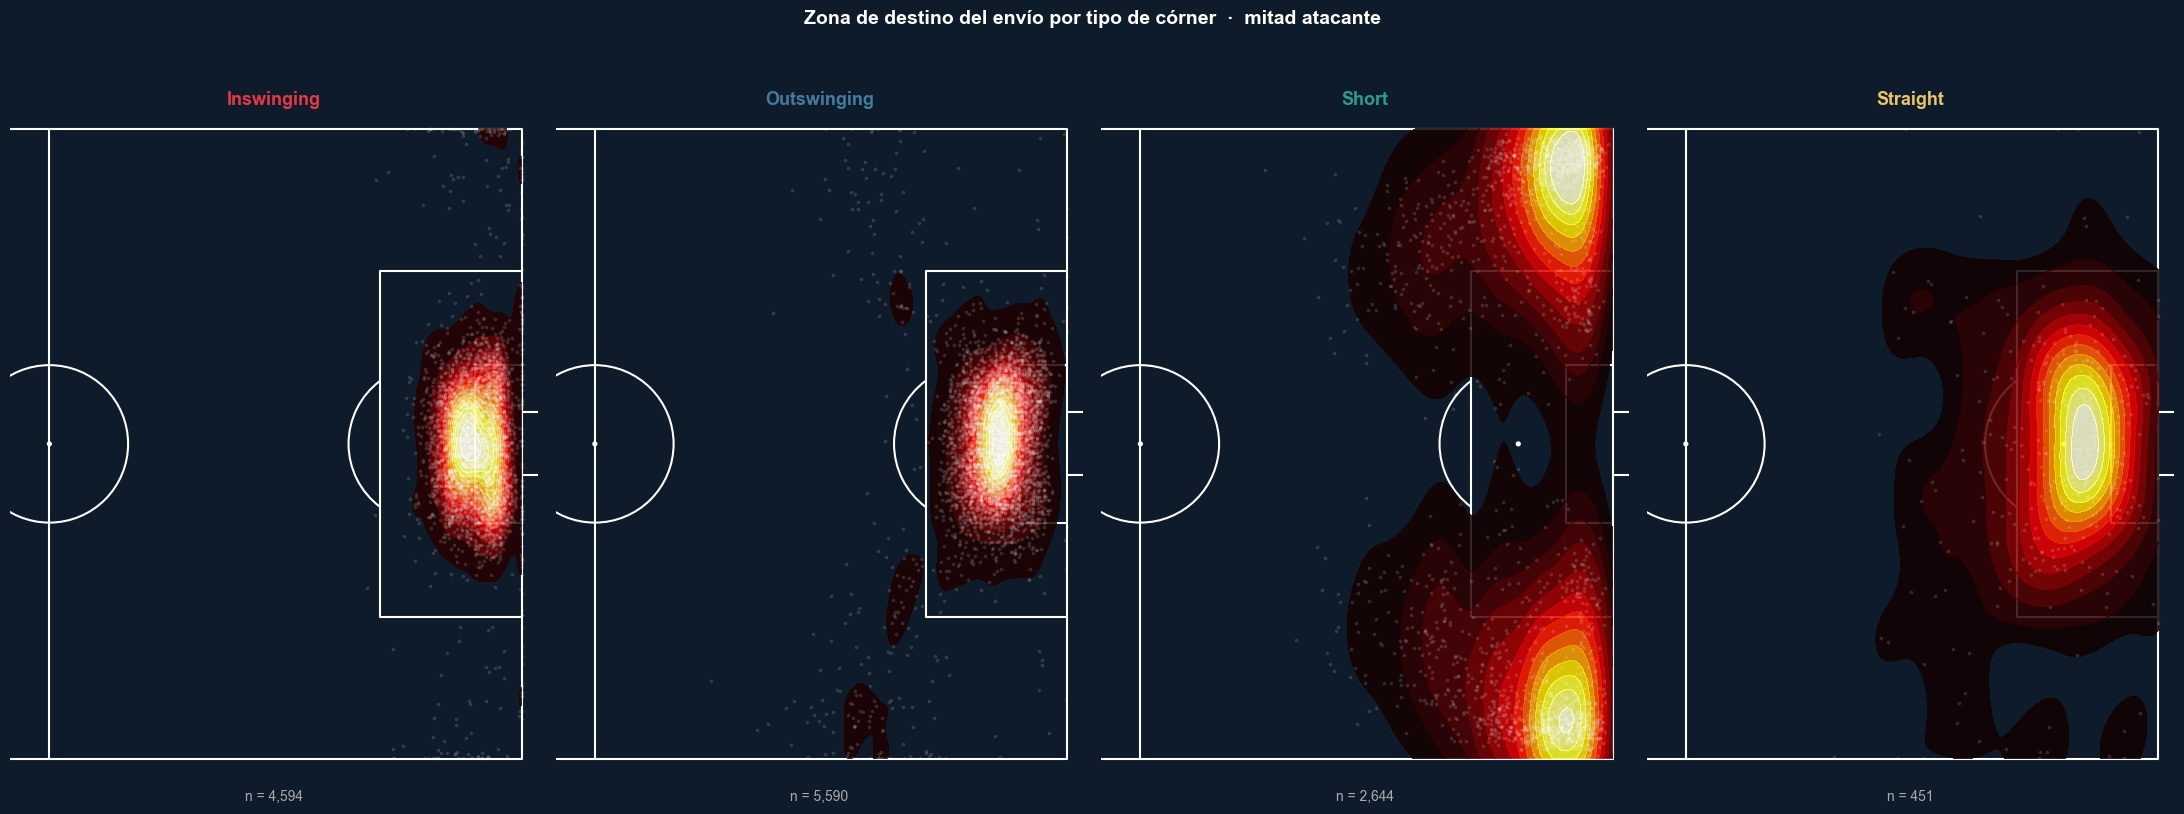

In [263]:
# ── 4.4 · Zona de destino del envío — vista de mitad atacante ───────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 8))

for ax, ctype, color in zip(axes, TYPES, COLORS_TYPE):
    pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff66',
                  linewidth=1.5, goal_type='box')
    pitch.draw(ax=ax)
    sub = corner_features[corner_features['corner_type'] == ctype].dropna(subset=['end_x', 'end_y'])
    if len(sub) > 10:
        pitch.kdeplot(sub['end_x'], sub['end_y'], ax=ax,
                      cmap='hot', fill=True, alpha=0.85, levels=14, thresh=0.04)
        pitch.scatter(sub['end_x'], sub['end_y'], ax=ax,
                      s=3, alpha=0.1, color='white', zorder=3)
    ax.set_xlim(55, 122)
    ax.set_ylim(-2, 82)
    ax.set_title(ctype, color=color, fontsize=13, fontweight='bold', pad=6)
    ax.text(0.5, -0.04, f'n = {len(sub):,}', transform=ax.transAxes,
            ha='center', color='#aaaaaa', fontsize=10)
    ax.set_facecolor(BG)

fig.patch.set_facecolor(BG)
fig.suptitle('Zona de destino del envío por tipo de córner  ·  mitad atacante',
             color='white', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/corner_delivery_zones.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### 4.5 · Distribución temporal

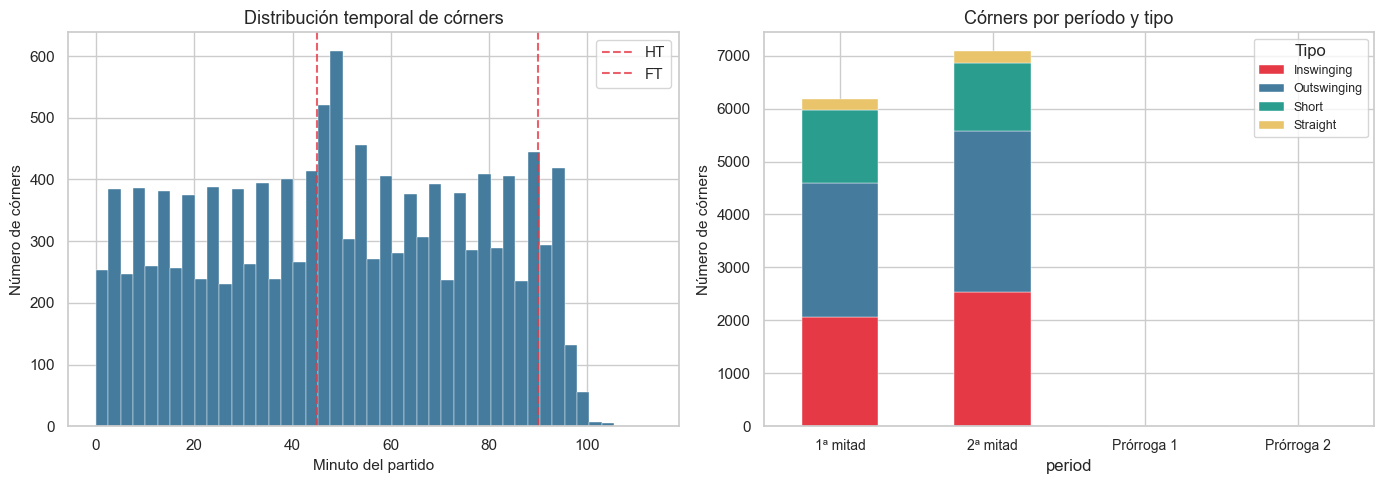

In [264]:
# ── 4.5 · Distribución temporal ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(corner_features['minute'], bins=45, color='#457b9d', edgecolor='white', linewidth=0.3)
for m, label in [(45, 'HT'), (90, 'FT')]:
    ax1.axvline(m, color='#e63946', linestyle='--', alpha=0.8, label=label)
ax1.set_xlabel('Minuto del partido', fontsize=11)
ax1.set_ylabel('Número de córners', fontsize=11)
ax1.set_title('Distribución temporal de córners', fontsize=13)
ax1.legend()

period_type = (
    corner_features
    .groupby(['period', 'corner_type'], observed=True)['id'].count()
    .unstack(fill_value=0)
    .reindex(columns=TYPES, fill_value=0)
)
period_type.index = period_type.index.map(
    {1: '1ª mitad', 2: '2ª mitad', 3: 'Prórroga 1', 4: 'Prórroga 2'}
)
period_type.plot(kind='bar', stacked=True, ax=ax2, color=COLORS_TYPE, edgecolor='white', linewidth=0.3)
ax2.set_title('Córners por período y tipo', fontsize=13)
ax2.set_ylabel('Número de córners', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=10)
ax2.legend(title='Tipo', fontsize=9)
plt.tight_layout()
plt.savefig('figures/corner_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 · Lado del córner y pie de envío

In [265]:
# ── 4.6 · Lado del córner × pie de envío ─────────────────────────────────────
# Pie dominante en córner = pie CONTRARIO al banderín:
#   • córner izquierdo (y<40) + pie DERECHO → bola curva hacia dentro → Inswinging
#   • córner derecho  (y>40) + pie IZQUIERDO → bola curva hacia dentro → Inswinging
#   • mismo lado (cruzado) → bola sale alejándose → Outswinging / Straight

side_body = (
    corner_features
    .groupby(['corner_side', 'pass_body_part'], observed=True)['id'].count()
    .unstack(fill_value=0)
)
print('Lado × pie de envío (nº de córners):')
print(side_body)

dominant = (
    ((corner_features['corner_side'] == 'left')  & (corner_features['pass_body_part'] == 'Right Foot')) |
    ((corner_features['corner_side'] == 'right') & (corner_features['pass_body_part'] == 'Left Foot'))
)
print(f'\nPie dominante (contrario al banderín): {dominant.mean():.1%}  ({dominant.sum():,})')
print(f'Pie cruzado   (mismo lado que banderín): {(~dominant).mean():.1%}  ({(~dominant).sum():,})')

print('\n% pie dominante por tipo (inswing=100%, outswing=0% es lo esperado físicamente):')
dom_by_type = (
    corner_features
    .assign(dominant_foot=dominant)
    .groupby('corner_type', observed=True)['dominant_foot']
    .mean().mul(100).round(1)
    .reindex(TYPES)
)
print(dom_by_type.to_string())
print('\n→ Inswinging: siempre pie dominante · Outswinging: siempre pie cruzado')
print('  Short y Straight mezclan ambos (no hay swinging commitment).')

Lado × pie de envío (nº de córners):
pass_body_part  Left Foot  Right Foot
corner_side                          
left                 2563        3868
right                2717        4131

Pie dominante (contrario al banderín): 49.6%  (6,585)
Pie cruzado   (mismo lado que banderín): 50.4%  (6,694)

% pie dominante por tipo (inswing=100%, outswing=0% es lo esperado físicamente):
corner_type
Inswinging     100.0
Outswinging      0.0
Short           66.1
Straight        53.9

→ Inswinging: siempre pie dominante · Outswinging: siempre pie cruzado
  Short y Straight mezclan ambos (no hay swinging commitment).


### 4.7 · Visualizaciones de resumen

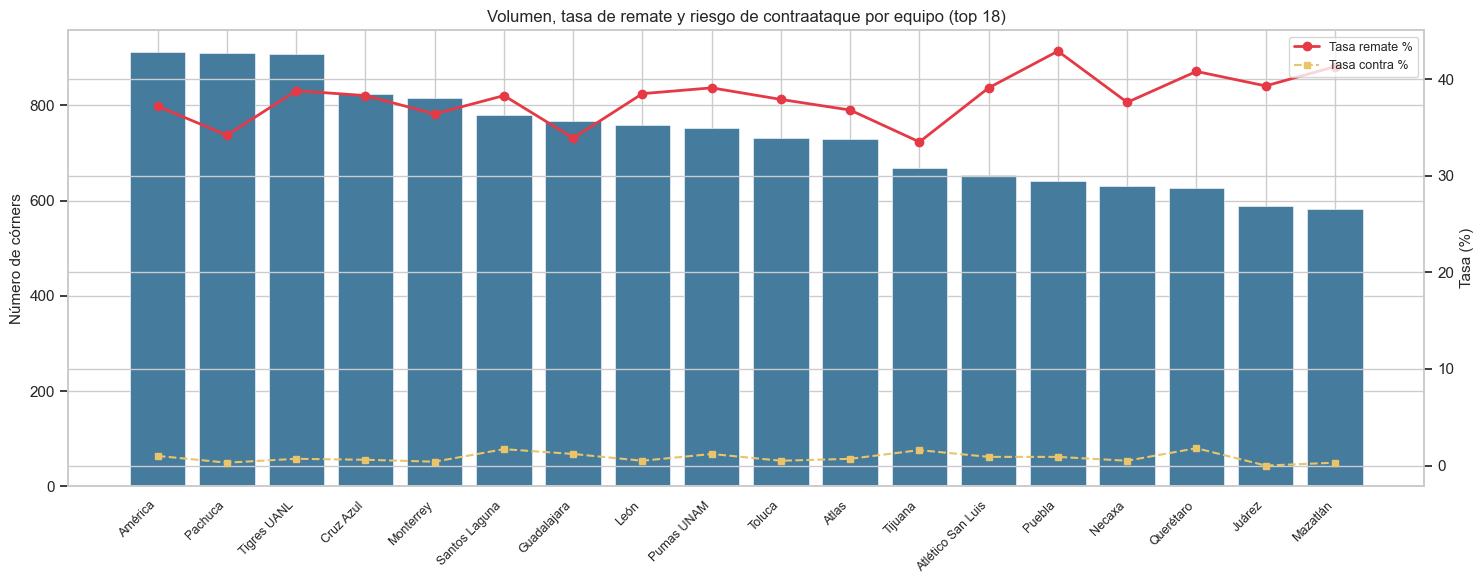

In [266]:
# ── Volumen, tasa de remate y riesgo por equipo (top 18) ─────────────────────
top18 = team_stats.nlargest(18, 'n_corners').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(top18['team'], top18['n_corners'], color='#457b9d', edgecolor='white', linewidth=0.4)
ax2 = ax.twinx()
ax2.plot(range(len(top18)), top18['shot_rate'],    'o-', color='#e63946', lw=2, ms=6, label='Tasa remate %')
ax2.plot(range(len(top18)), top18['counter_rate'], 's--', color='#e9c46a', lw=1.5, ms=5, label='Tasa contra %')
ax.set_ylabel('Número de córners', fontsize=11)
ax2.set_ylabel('Tasa (%)', fontsize=11)
ax.set_xticklabels(top18['team'], rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=9, loc='upper right')
ax.set_title('Volumen, tasa de remate y riesgo de contraataque por equipo (top 18)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/team_corner_volume.png', dpi=150, bbox_inches='tight')
plt.show()

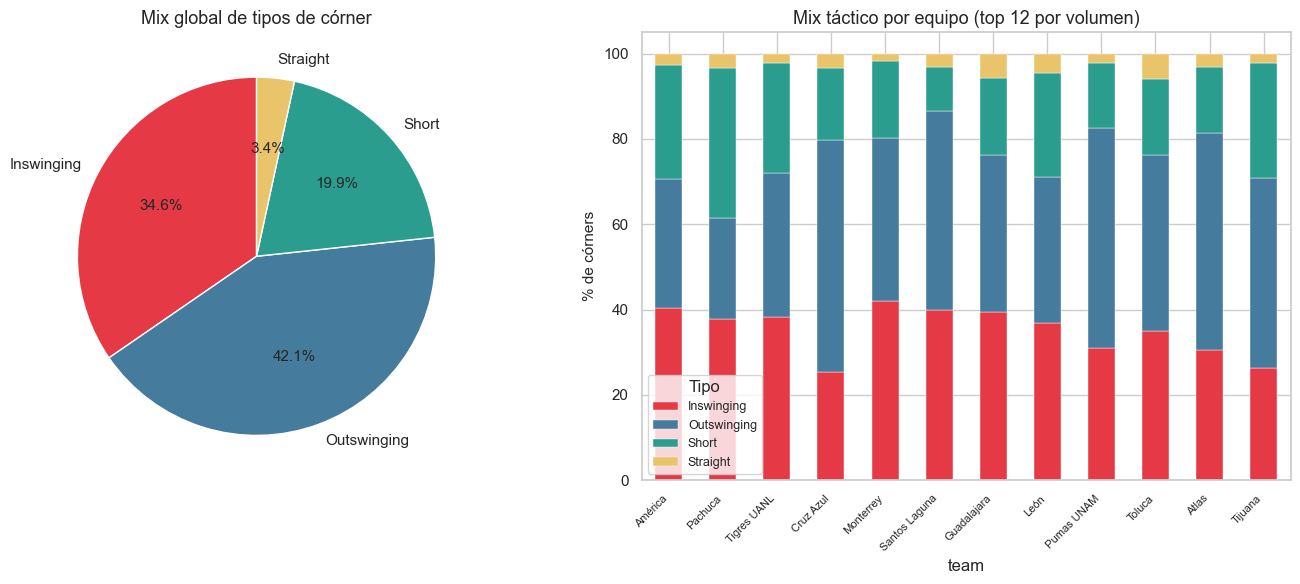

In [267]:
# ── Mix global (pie) y por equipo (barras apiladas) ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(type_mix['n'], labels=type_mix['corner_type'], autopct='%1.1f%%',
        colors=COLORS_TYPE, startangle=90, textprops={'fontsize': 11})
ax1.set_title('Mix global de tipos de córner', fontsize=13)

top12 = (
    corner_features
    .groupby(['team', 'corner_type'], observed=True)['id'].count()
    .unstack(fill_value=0)
)
top12 = top12.loc[top12.sum(axis=1).nlargest(12).index]
top12_pct = (
    top12.div(top12.sum(axis=1), axis=0)
    .mul(100)
    .reindex(columns=TYPES, fill_value=0)
)
top12_pct.plot(kind='bar', stacked=True, ax=ax2, color=COLORS_TYPE, edgecolor='white', linewidth=0.3)
ax2.set_title('Mix táctico por equipo (top 12 por volumen)', fontsize=13)
ax2.set_ylabel('% de córners', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax2.legend(title='Tipo', fontsize=9)
plt.tight_layout()
plt.savefig('figures/corner_type_mix.png', dpi=150, bbox_inches='tight')
plt.show()

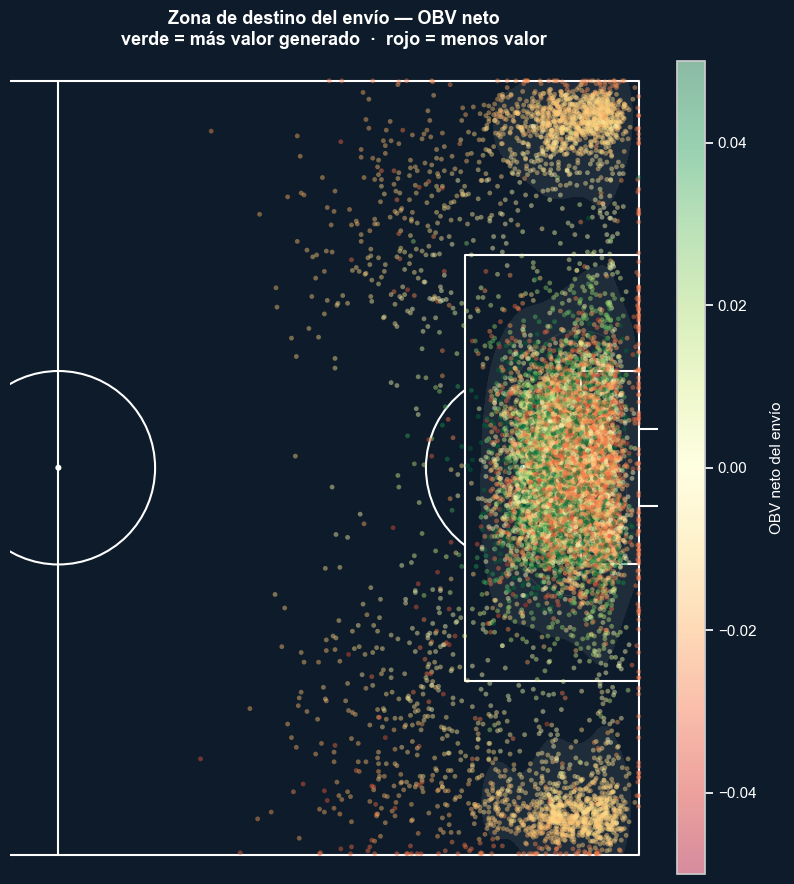

In [268]:
# ── Destino del envío coloreado por OBV ──────────────────────────────────────
BG = '#0d1b2a'
fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff55',
              linewidth=1.5, goal_type='box')
pitch.draw(ax=ax)

sub = corner_features.dropna(subset=['end_x', 'end_y', 'obv_total_net'])

# Densidad de fondo (todos los córners)
pitch.kdeplot(sub['end_x'], sub['end_y'], ax=ax,
              cmap='Greys', alpha=0.08, fill=True, levels=6, thresh=0.1)

# Scatter coloreado por OBV
sc = pitch.scatter(sub['end_x'], sub['end_y'], ax=ax,
                   c=sub['obv_total_net'], cmap='RdYlGn',
                   s=12, alpha=0.45, zorder=3,
                   vmin=-0.05, vmax=0.05, linewidths=0)

cbar = fig.colorbar(sc, ax=ax, orientation='vertical',
                    pad=0.015, fraction=0.025, aspect=30)
cbar.set_label('OBV neto del envío', color='white', fontsize=11, labelpad=10)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

ax.set_xlim(55, 122)
ax.set_ylim(-2, 82)
ax.set_title('Zona de destino del envío — OBV neto\n'
             'verde = más valor generado  ·  rojo = menos valor',
             color='white', fontsize=13, pad=12, fontweight='bold')
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('figures/delivery_obv_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

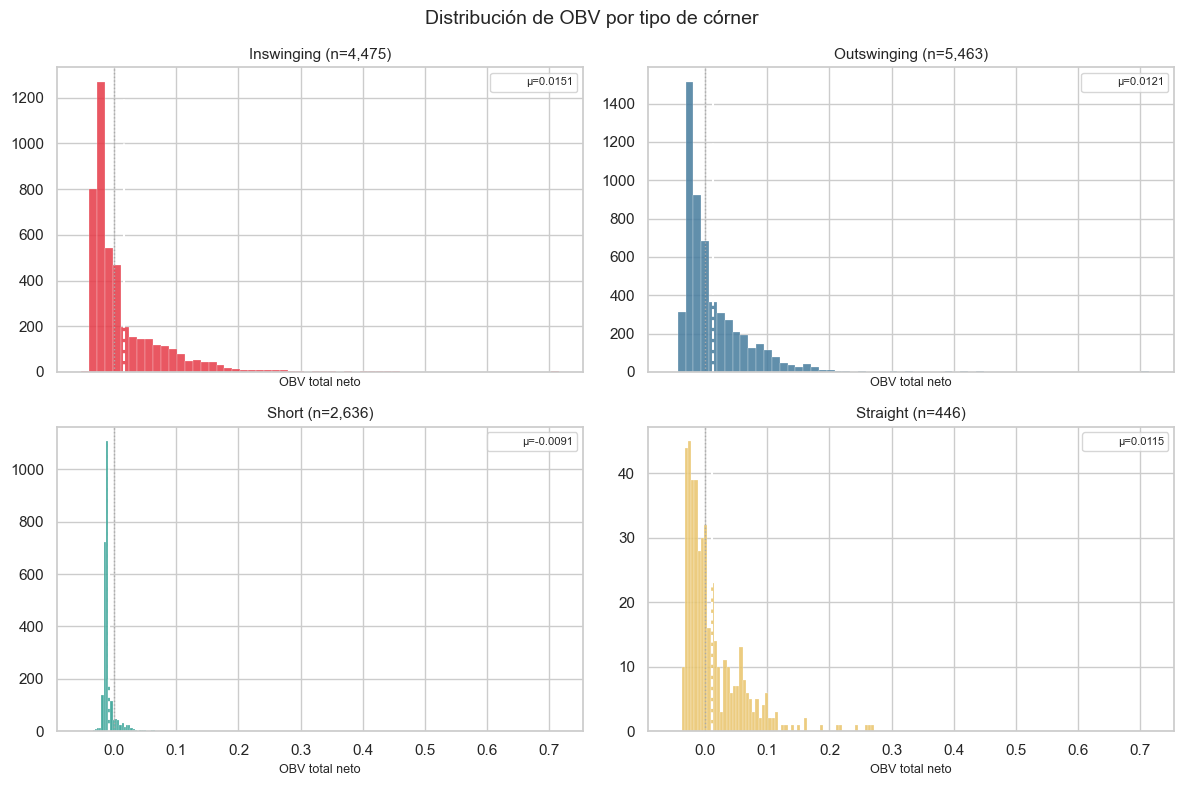

In [269]:
# ── Distribución de OBV por tipo de córner ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, ctype, color in zip(axes.flat, TYPES, COLORS_TYPE):
    data = corner_features[corner_features['corner_type'] == ctype]['obv_total_net'].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.85, edgecolor='white', linewidth=0.2)
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.4f}')
    ax.axvline(0, color='#aaaaaa', linestyle=':', linewidth=1)
    ax.set_title(f'{ctype} (n={len(data):,})', fontsize=11)
    ax.set_xlabel('OBV total neto', fontsize=9)
    ax.legend(fontsize=8)
fig.suptitle('Distribución de OBV por tipo de córner', fontsize=14)
plt.tight_layout()
plt.savefig('figures/obv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.8 · Zonas de remate por origen

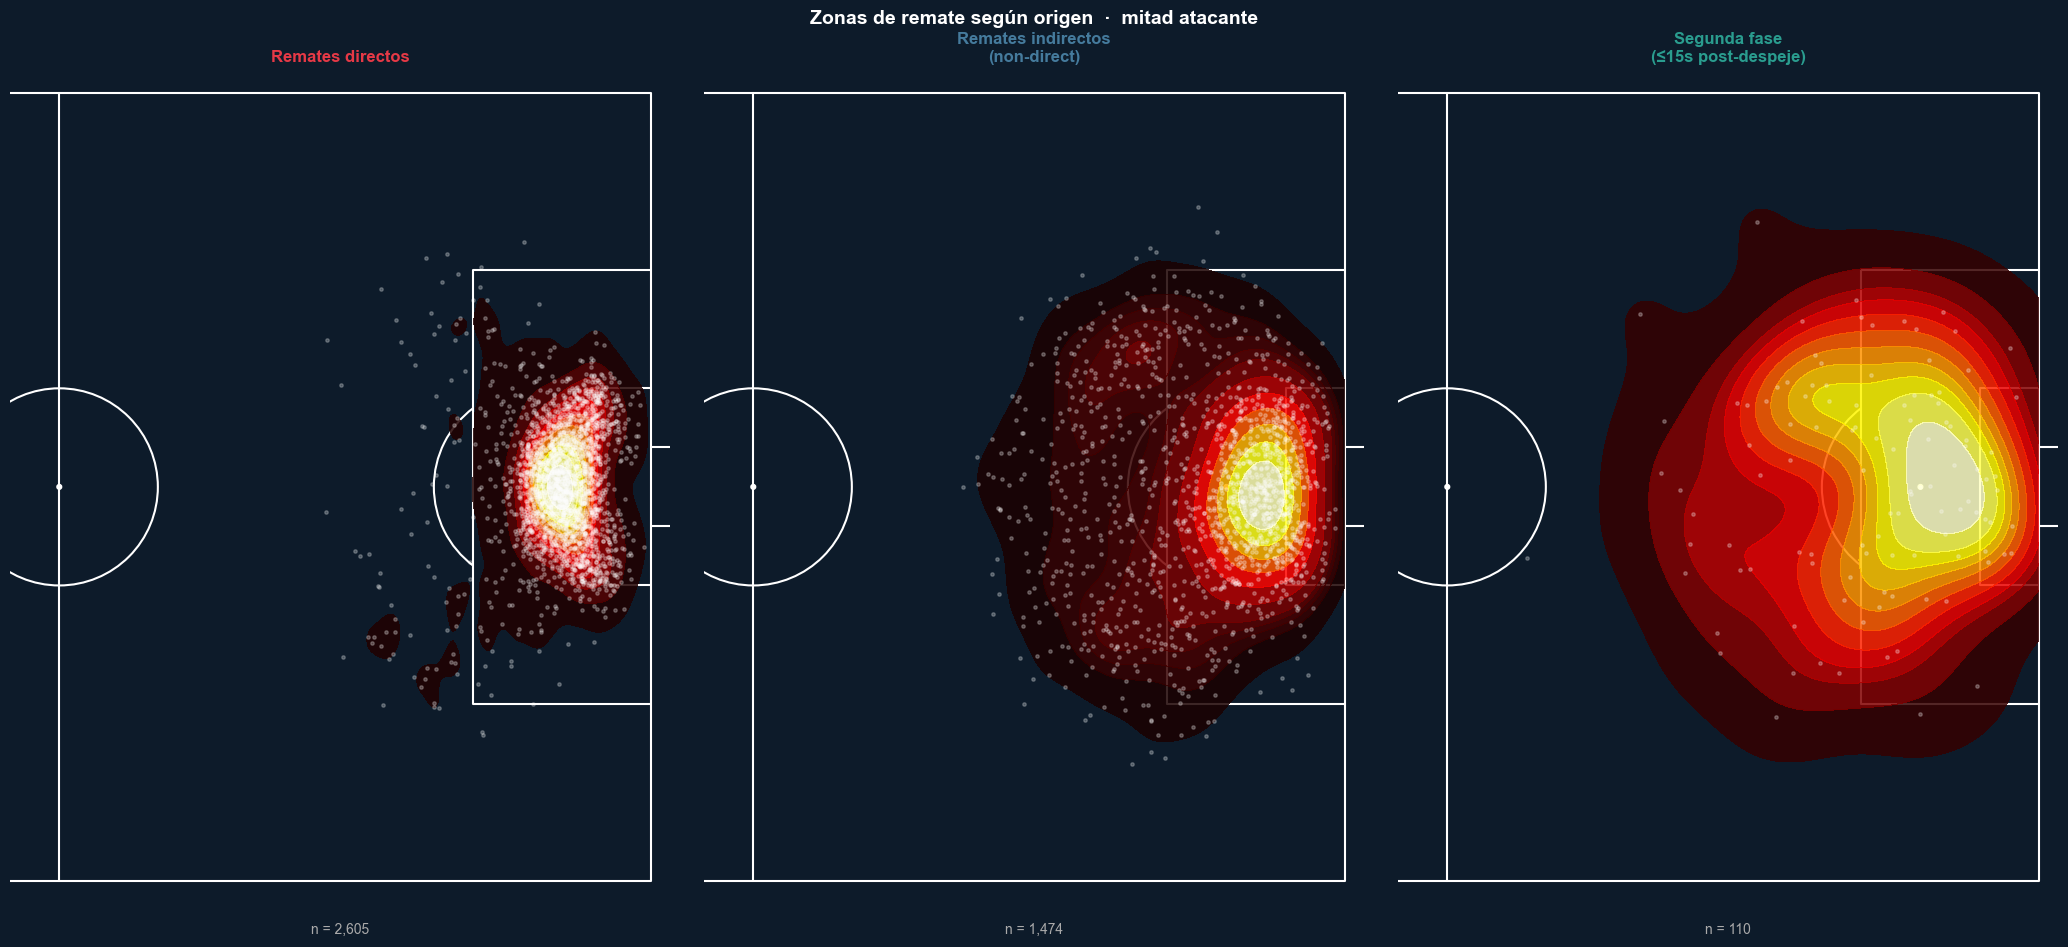

In [270]:
# ── 4.8 · Zonas de remate por origen ─────────────────────────────────────────
def get_xy(df, col='location'):
    """Extrae x, y de columnas que pueden ser list, tuple o numpy array."""
    locs = df[col].dropna()
    xs = locs.apply(lambda l: float(l[0]) if hasattr(l, '__len__') and len(l) >= 2 else None).dropna()
    ys = locs.apply(lambda l: float(l[1]) if hasattr(l, '__len__') and len(l) >= 2 else None).dropna()
    return xs.values, ys.values

datasets = [
    ('Remates directos',                   shots_fc[shots_fc['shot_origin'] == 'direct'],     '#e63946'),
    ('Remates indirectos\n(non-direct)',   shots_fc[shots_fc['shot_origin'] == 'non_direct'], '#457b9d'),
    ('Segunda fase\n(≤15s post-despeje)',  shots_sp,                                           '#2a9d8f'),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 9))
for ax, (title, df, color) in zip(axes, datasets):
    pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff66',
                  linewidth=1.5, goal_type='box')
    pitch.draw(ax=ax)
    xs, ys = get_xy(df)
    if len(xs) > 5:
        pitch.kdeplot(xs, ys, ax=ax, cmap='hot', fill=True, alpha=0.85, levels=12, thresh=0.04)
        pitch.scatter(xs, ys, ax=ax, s=6, alpha=0.25, color='white', zorder=4)
    ax.set_xlim(55, 122)
    ax.set_ylim(-2, 82)
    ax.set_title(title, color=color, fontsize=12, fontweight='bold', pad=8)
    ax.text(0.5, -0.04, f'n = {len(df):,}', transform=ax.transAxes,
            ha='center', color='#aaaaaa', fontsize=10)
    ax.set_facecolor(BG)

fig.patch.set_facecolor(BG)
fig.suptitle('Zonas de remate según origen  ·  mitad atacante',
             color='white', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/shot_locations.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### 4.9 · Córner aleatorio — jugadores en cancha

Usa el freeze frame 360 si está disponible (jugadores en posición real al momento del remate). Fallback: traza de eventos de la secuencia. Cada ejecución muestra un córner distinto.

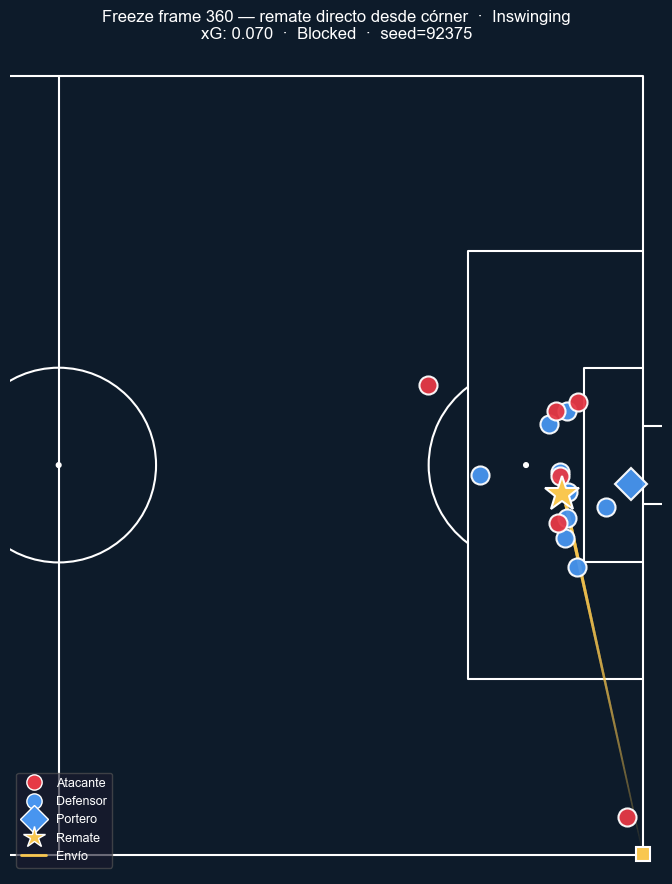

In [299]:
# ── 4.9 · Córner aleatorio — jugadores en cancha ─────────────────────────────
# Cada ejecución muestra un córner distinto. Fija rng_seed para reproducir.
import random
rng_seed = random.randint(0, 99999)

ff_col = next((c for c in shots_fc.columns if 'freeze_frame' in c.lower()), None)

# Solo remates DIRECTOS desde córner: aseguran que la jugada luzca como córner
direct_ff = (
    shots_fc[
        (shots_fc['shot_origin'] == 'direct') &
        shots_fc[ff_col].notna()
    ]
    if ff_col else pd.DataFrame()
)

fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff66',
              linewidth=1.5, goal_type='box')
pitch.draw(ax=ax)

if len(direct_ff) > 0:
    row     = direct_ff.sample(1, random_state=rng_seed).iloc[0]
    ff      = list(row[ff_col]) if hasattr(row[ff_col], '__len__') else []

    # Flecha de entrega: búscamos el córner que asistió este remate
    corner_row = corner_features[corner_features['id'] == row['shot_key_pass_id']]
    if len(corner_row) > 0:
        cr = corner_row.iloc[0]
        if pd.notna(cr['corner_x']) and pd.notna(cr['end_x']):
            pitch.lines(float(cr['corner_x']), float(cr['corner_y']),
                        float(cr['end_x']),    float(cr['end_y']),
                        ax=ax, color='#f9c74f', lw=2.5, zorder=4,
                        comet=True, transparent=True)
            ax.plot(float(cr['corner_x']), float(cr['corner_y']),
                    's', color='#f9c74f', ms=10, mec='white', mew=1.5, zorder=5)

    # Jugadores del freeze frame
    for player in ff:
        loc     = player.get('location')
        if not hasattr(loc, '__len__') or len(loc) < 2:
            continue
        is_att  = player.get('teammate', False)
        # GK: StatsBomb no tiene campo 'keeper'; se identifica por position.id == 1
        pos_id  = player.get('position', {}).get('id') if isinstance(player.get('position'), dict) else None
        is_gk   = (pos_id == 1)
        color   = '#e63946' if is_att else '#4895ef'
        marker  = 'D' if is_gk else 'o'
        size    = 16 if is_gk else 13
        ax.plot(float(loc[0]), float(loc[1]), marker=marker, color=color,
                ms=size, alpha=0.95, mec='white', mew=1.5, zorder=6)

    # Estrella en el punto de remate
    sloc = row['location']
    if hasattr(sloc, '__len__') and len(sloc) >= 2:
        ax.plot(float(sloc[0]), float(sloc[1]), '*', color='#f9c74f',
                ms=26, zorder=8, mec='white', mew=1.5)

    xg  = row.get('shot_statsbomb_xg', float('nan'))
    out = row.get('shot_outcome', 'N/A')
    ct  = corner_row.iloc[0]['corner_type'] if len(corner_row) > 0 else '?'
    title = (f'Freeze frame 360 — remate directo desde córner  ·  {ct}\n'
             f'xG: {xg:.3f}  ·  {out}  ·  seed={rng_seed}')
    legend_items = [
        plt.Line2D([0],[0], marker='o', color='#e63946', ms=11, mec='white', label='Atacante',  linestyle=''),
        plt.Line2D([0],[0], marker='o', color='#4895ef', ms=11, mec='white', label='Defensor',  linestyle=''),
        plt.Line2D([0],[0], marker='D', color='#4895ef', ms=14, mec='white', label='Portero',   linestyle=''),
        plt.Line2D([0],[0], marker='*', color='#f9c74f', ms=16, mec='white', label='Remate',    linestyle=''),
        plt.Line2D([0],[0], color='#f9c74f', lw=2,                           label='Envío',     linestyle='-'),
    ]
else:
    # Fallback: traza de eventos de la secuencia
    rc  = corner_features.sample(1, random_state=rng_seed).iloc[0]
    seq = from_corner_enr[
        (from_corner_enr['match_id'] == rc['match_id']) &
        (from_corner_enr['possession'] == rc['possession'])
    ]
    if pd.notna(rc['corner_x']) and pd.notna(rc['end_x']):
        pitch.lines(float(rc['corner_x']), float(rc['corner_y']),
                    float(rc['end_x']),    float(rc['end_y']),
                    ax=ax, color='#f9c74f', lw=2.5, zorder=5,
                    comet=True, transparent=True)
    COLOR_EVENT = {'Shot': '#e63946', 'Clearance': '#4895ef', 'Duel': '#f9c74f',
                   'Carry': '#aaaaaa', 'Goal Keeper': '#f4a261', 'Ball Recovery': '#2a9d8f'}
    plotted = {}
    for _, ev in seq.iterrows():
        loc = ev['location']
        if not hasattr(loc, '__len__') or len(loc) < 2:
            continue
        c = COLOR_EVENT.get(ev['type'], '#ffffff88')
        ax.plot(float(loc[0]), float(loc[1]), 'o', color=c, ms=11,
                alpha=0.9, mec='white', mew=1, zorder=6)
        plotted[ev['type']] = c
    title = (f'{rc["corner_type"]}  ·  {rc["corner_side"]} side  ·  {rc["sequence_outcome"]}\n'
             f'{rc.get("team", "")}  ·  seed={rng_seed}')
    legend_items = [
        plt.Line2D([0],[0], marker='o', color=c, ms=10, mec='white', label=t, linestyle='')
        for t, c in plotted.items()
    ]

ax.set_xlim(55, 122)
ax.set_ylim(-2, 82)
ax.legend(handles=legend_items, loc='lower left', fontsize=9,
          framealpha=0.65, facecolor='#1a1a2e', labelcolor='white', edgecolor='#555')
ax.set_title(title, color='white', fontsize=12, pad=12)
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

## 5 · Efectividad - OBV y xG

In [272]:
# TODO: OBV y tasa de remate por corner_type
# corner_features.groupby('corner_type').agg(
#     n          = ('id','count'),
#     obv_mean   = ('obv_total_net','mean'),
#     shot_rate  = ('generated_shot','mean'),
#     xg_mean    = ('seq_max_xg','mean'),
# )
# OBV captura el valor de TODOS los córners, no solo los que terminan en remate
# Eso es la ventaja competitiva de este análisis vs enfoques solo-xG

In [273]:
# TODO: xG por tipo de remate - comparar las 3 fuentes de peligro
# Fuente 1 (directo):   corner_features[corner_features['best_shot_origin']=='direct']['best_shot_statsbomb_xg']
# Fuente 2 (indirecto): corner_features[corner_features['best_shot_origin']=='indirect']['best_shot_statsbomb_xg']
# Fuente 3 (2da fase):  df_second_phase['shot_statsbomb_xg']
#
# TODO (innovador): shot_execution_xg_uplift - ¿qué equipos tienen rematadores que
# convierten mejor las oportunidades de córner que el promedio?
# corner_features.groupby('team')['best_shot_execution_xg_uplift'].mean()
#
# TODO: OBV defensivo de despejes - cuánto recupera la defensa
# from_corner[from_corner['type']=='Clearance'].groupby('team')['obv_total_net'].mean()

In [274]:
# TODO: riesgo vs recompensa por tipo de córner
# La pregunta táctica central: ¿vale la pena el riesgo de contraataque?
#
# corner_features.groupby('corner_type').agg(
#     shot_rate    = ('generated_shot', 'mean'),   # recompensa ofensiva
#     counter_rate = ('led_to_counter', 'mean'),   # riesgo defensivo
#     retained_rate = ('sequence_outcome', lambda x: (x=='retained').mean()),
#     xg_mean      = ('seq_max_xg', 'mean'),
#     obv_mean     = ('obv_total_net', 'mean'),
# )
#
# Hipótesis: Short corners tienen mayor counter_rate (más jugadores descolocados)
# Hipótesis: Inswinging tiene mayor shot_rate que Outswinging
# Test: Mann-Whitney para xG entre tipos
# stats.mannwhitneyu(inswing_xg, outswing_xg, alternative='two-sided')

## 6 · Análisis espacial 360

In [275]:
# TODO: extraer shot_freeze_frame de los remates precedidos por córner
# Cada freeze frame tiene posiciones de atacantes y defensores en el momento del remate
# → promedio de jugadores en el área chica, zona 6-yard box vs zona penal

In [276]:
# TODO: heatmap de posiciones de atacantes en corners que resultaron en remate vs los que no
# pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')

## 7 · Modelo predictivo

In [277]:
# TODO: feature matrix — usar corner_features directamente
# features_cat = ['corner_type', 'corner_side', 'pass_height', 'pass_pass_cluster_label', 'season']
# features_num = ['pass_length', 'pass_angle', 'obv_total_net', 'pass_pass_success_probability',
#                 'num_defenders_on_goal_side_of_actor', 'distance_to_nearest_defender',
#                 'visible_opponents', 'visible_teammates']
#
# X = pd.get_dummies(corner_features[features_cat + features_num], drop_first=True)
# y = corner_features['generated_shot'].astype(int)
#
# Target alternativo (más exigente): seq_max_xg > 0.07
# y_xg = (corner_features['seq_max_xg'].fillna(0) > 0.07).astype(int)

In [278]:
# TODO: entrenar Random Forest + cross-validation
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

In [279]:
# TODO: SHAP - qué features importan más
# explainer = shap.TreeExplainer(rf)
# shap.summary_plot(shap_values, X)

## 8 · Recomendaciones tácticas

In [280]:
# TODO: simulación de cambio de mix
# "Si X equipo reemplaza 20% de outswingers por córners cortos → estimación de shots y xG"
# Comparar vs baseline actual de ese equipo

In [281]:
# TODO: tabla resumen por equipo - mix actual vs mix recomendado vs delta xG esperado

## 9 · Visualización final

In [282]:
# TODO: pitch map de zonas de destino por tipo de córner
# pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
# fig, ax = pitch.draw(figsize=(12,8))
# plt.savefig('figures/corner_zones.png', dpi=150, bbox_inches='tight')

In [283]:
# TODO: gráfica interactiva de OBV por equipo y temporada (plotly)
# Para el entregable HTML - los plots interactivos se renderizan al exportar